In [1]:
# CELL 1: Complete Setup with All Imports
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.quantization as quant
from torch.quantization import quantize_dynamic
import numpy as np
import matplotlib.pyplot as plt
import cv2
from PIL import Image
import os
import time
import random
from pathlib import Path
import timm
import warnings
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
warnings.filterwarnings('ignore')

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Create directories
os.makedirs("./test_results", exist_ok=True)
os.makedirs("./models_compressed", exist_ok=True)
os.makedirs("./deployment_package", exist_ok=True)

CLASS_NAMES = ['covid', 'other', 'healthy']

Using device: cpu


In [2]:
# CELL 2: Define Model Architectures
# Model 5 (Segmentation - EfficientNet-B3 + SegFormer)
class EfficientNetEncoder_B3(nn.Module):
    def __init__(self, model_name='efficientnet_b3', pretrained=False):
        super().__init__()
        self.backbone = timm.create_model(model_name, pretrained=pretrained, features_only=True)
        self.feature_channels = self.backbone.feature_info.channels()
    
    def forward(self, x):
        return self.backbone(x)

class SegFormerDecoder(nn.Module):
    def __init__(self, encoder_channels, num_classes=1, decoder_dim=256):
        super().__init__()
        self.proj = nn.ModuleList()
        for in_ch in encoder_channels:
            self.proj.append(nn.Sequential(
                nn.Conv2d(in_ch, decoder_dim, 1), nn.BatchNorm2d(decoder_dim), nn.ReLU(inplace=True)
            ))
        self.fusion = nn.Sequential(
            nn.Conv2d(decoder_dim * len(encoder_channels), decoder_dim, 1),
            nn.BatchNorm2d(decoder_dim), nn.ReLU(inplace=True),
            nn.Conv2d(decoder_dim, decoder_dim, 3, padding=1), nn.BatchNorm2d(decoder_dim), nn.ReLU(inplace=True),
            nn.Conv2d(decoder_dim, num_classes, 1)
        )
    
    def forward(self, features):
        target_size = features[0].shape[2]
        projected = []
        for i, feat in enumerate(features):
            proj = self.proj[i](feat)
            if proj.shape[2] != target_size:
                proj = F.interpolate(proj, size=(target_size, target_size), mode='bilinear')
            projected.append(proj)
        concat = torch.cat(projected, dim=1)
        out = self.fusion(concat)
        out = F.interpolate(out, size=(224, 224), mode='bilinear')
        return out

class Model5_Segmentation(nn.Module):
    def __init__(self, num_seg_classes=1):
        super().__init__()
        self.encoder = EfficientNetEncoder_B3('efficientnet_b3', pretrained=False)
        encoder_channels = self.encoder.feature_channels
        self.seg_decoder = SegFormerDecoder(encoder_channels, num_seg_classes, decoder_dim=256)
    
    def forward(self, x):
        features = self.encoder(x)
        seg_out = self.seg_decoder(features)
        return seg_out

# Model L1 (Classification - EfficientNet-B0)
class ModelL1_Classification(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()
        self.encoder = timm.create_model('efficientnet_b0', pretrained=False, features_only=True)
        encoder_channels = self.encoder.feature_info.channels()[-1]
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(encoder_channels, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),
            nn.Linear(256, num_classes)
        )
    
    def forward(self, x):
        features = self.encoder(x)
        class_out = self.classifier(features[-1])
        return class_out

# Ensemble Model
class EnsembleModel(nn.Module):
    def __init__(self, classifier, segmenter):
        super().__init__()
        self.classifier = classifier
        self.segmenter = segmenter
    
    def forward(self, x):
        class_out = self.classifier(x)
        seg_out = self.segmenter(x)
        return class_out, seg_out

print("✅ Model architectures defined")

✅ Model architectures defined


In [3]:
# CELL 3: Load Trained Models
model5 = Model5_Segmentation(num_seg_classes=1)
model5_path = "./models/model5_best_acc.pth"
model5_loaded = False

modelL1 = ModelL1_Classification(num_classes=3)
modelL1_paths = ["./models_lightweight/L1_EfficientNet_best.pth", "./models_lightweight/L1_EfficientNet_SegFormerLite_best.pth"]
modelL1_loaded = False

# Load Model 5
if os.path.exists(model5_path):
    try:
        state_dict = torch.load(model5_path, map_location=device)
        model5.load_state_dict(state_dict, strict=False)
        model5.to(device)
        model5.eval()
        model5_loaded = True
        print(f"✅ Model 5 loaded")
    except Exception as e:
        print(f"Error loading Model 5: {e}")

# Load Model L1
for path in modelL1_paths:
    if os.path.exists(path):
        try:
            state_dict = torch.load(path, map_location=device)
            modelL1.load_state_dict(state_dict, strict=False)
            modelL1.to(device)
            modelL1.eval()
            modelL1_loaded = True
            print(f"✅ Model L1 loaded from {path}")
            break
        except Exception as e:
            print(f"Error loading from {path}: {e}")

# Create Ensemble
ensemble = None
if modelL1_loaded and model5_loaded:
    ensemble = EnsembleModel(modelL1, model5)
    ensemble.to(device)
    ensemble.eval()
    print("✅ Ensemble created")

✅ Model 5 loaded
✅ Model L1 loaded from ./models_lightweight/L1_EfficientNet_best.pth
✅ Ensemble created


In [4]:
# CELL 4: Preprocessing and Test Images
def preprocess_image(image_path, img_size=224):
    if isinstance(image_path, str):
        image = cv2.imread(image_path)
        if image is None:
            raise FileNotFoundError(f"Could not load: {image_path}")
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    else:
        image = image_path.copy()
    
    original = image.copy()
    image = cv2.resize(image, (img_size, img_size))
    img_tensor = torch.from_numpy(image.astype(np.float32) / 255.0).permute(2, 0, 1).unsqueeze(0)
    return img_tensor, original

# Find test images
TEST_PATH = r"C:/Users/Administrator/classification/test"
test_images = []

if os.path.exists(TEST_PATH):
    for class_name in CLASS_NAMES:
        class_path = os.path.join(TEST_PATH, class_name)
        if os.path.exists(class_path):
            for img in Path(class_path).glob('*.jpg'):
                test_images.append((str(img), class_name))
            for img in Path(class_path).glob('*.png'):
                test_images.append((str(img), class_name))
    print(f"Found {len(test_images)} test images")
else:
    print(f"Test path not found: {TEST_PATH}")

Found 84 test images


In [5]:
# CELL 5: Get Model Size Function
def get_model_size(model):
    """Calculate model size in MB"""
    param_size = sum(p.numel() * p.element_size() for p in model.parameters())
    buffer_size = sum(b.numel() * b.element_size() for b in model.buffers())
    size_mb = (param_size + buffer_size) / 1024 / 1024
    return size_mb

def count_parameters(model):
    """Count trainable parameters"""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

In [6]:
# CELL 6: Apply Dynamic Quantization
def compress_model(model, model_name):
    """Apply dynamic quantization to model"""
    model_cpu = model.cpu()
    model_cpu.eval()
    
    try:
        quantized_model = quantize_dynamic(
            model_cpu,
            {nn.Linear, nn.Conv2d},
            dtype=torch.qint8
        )
        quantized_size = get_model_size(quantized_model)
        print(f"  ✅ {model_name}: {get_model_size(model_cpu):.2f} MB → {quantized_size:.2f} MB")
        return quantized_model, quantized_size
    except Exception as e:
        print(f"  ⚠️ {model_name}: Quantization failed - {str(e)[:50]}")
        return model_cpu, get_model_size(model_cpu)

print("\n" + "="*60)
print("APPLYING QUANTIZATION")
print("="*60)

# Compress models
quantized_models = {}

if modelL1_loaded:
    print("\nModel L1 (Classifier):")
    q_model, q_size = compress_model(modelL1, "Model L1")
    quantized_models['L1'] = {'model': q_model, 'size': q_size, 'original_size': get_model_size(modelL1)}

if model5_loaded:
    print("\nModel 5 (Segmenter):")
    q_model, q_size = compress_model(model5, "Model 5")
    quantized_models['M5'] = {'model': q_model, 'size': q_size, 'original_size': get_model_size(model5)}

if ensemble:
    print("\nEnsemble:")
    q_model, q_size = compress_model(ensemble, "Ensemble")
    quantized_models['Ensemble'] = {'model': q_model, 'size': q_size, 'original_size': get_model_size(ensemble)}
    


APPLYING QUANTIZATION

Model L1 (Classifier):
  ✅ Model L1: 14.18 MB → 13.87 MB

Model 5 (Segmenter):
  ✅ Model 5: 43.01 MB → 43.01 MB

Ensemble:
  ✅ Ensemble: 57.19 MB → 56.87 MB


In [7]:
# CELL 8: Accuracy Comparison
def evaluate_accuracy(model, test_images, device, max_samples=30):
    correct = 0
    total = 0
    
    for img_path, true_label in test_images[:max_samples]:
        try:
            img_tensor, _ = preprocess_image(img_path)
            img_tensor = img_tensor.to(device)
            
            with torch.no_grad():
                if isinstance(model, EnsembleModel):
                    class_out, _ = model(img_tensor)
                else:
                    class_out = model(img_tensor)
                
                probs = torch.softmax(class_out, dim=1)
                pred = torch.argmax(probs, dim=1).item()
            
            if CLASS_NAMES[pred] == true_label:
                correct += 1
            total += 1
        except Exception as e:
            print(f"Error: {e}")
    
    return correct / total * 100 if total > 0 else 0

print("\n" + "="*60)
print("ACCURACY COMPARISON")
print("="*60)

if test_images:
    if modelL1_loaded:
        acc_orig = evaluate_accuracy(modelL1, test_images, device, max_samples=30)
        print(f"Model L1 (Original): {acc_orig:.2f}%")
        
        if 'L1' in quantized_models:
            acc_quant = evaluate_accuracy(quantized_models['L1']['model'], test_images, torch.device('cpu'), max_samples=30)
            print(f"Model L1 (Quantized): {acc_quant:.2f}%")
            print(f"  Drop: {acc_orig - acc_quant:.2f}%\n")
    
    if ensemble:
        acc_ensemble = evaluate_accuracy(ensemble, test_images, device, max_samples=30)
        print(f"Ensemble (Original): {acc_ensemble:.2f}%")
        
        if 'Ensemble' in quantized_models:
            acc_ens_quant = evaluate_accuracy(quantized_models['Ensemble']['model'], test_images, torch.device('cpu'), max_samples=30)
            print(f"Ensemble (Quantized): {acc_ens_quant:.2f}%")
            print(f"  Drop: {acc_ensemble - acc_ens_quant:.2f}%")


ACCURACY COMPARISON
Model L1 (Original): 93.33%
Model L1 (Quantized): 93.33%
  Drop: 0.00%

Ensemble (Original): 93.33%
Ensemble (Quantized): 93.33%
  Drop: 0.00%


In [8]:
# CELL 14: FP16 Compression for All Models
import copy

print("\n" + "="*60)
print("FP16 COMPRESSION (RECOMMENDED)")
print("="*60)

# Create FP16 versions
fp16_models = {}

if modelL1_loaded:
    modelL1_fp16 = copy.deepcopy(modelL1)
    modelL1_fp16 = modelL1_fp16.half()
    modelL1_fp16.eval()
    
    # Verify FP16 works
    test_input = torch.randn(1, 3, 224, 224).half()
    try:
        with torch.no_grad():
            output = modelL1_fp16(test_input)
        fp16_models['L1'] = modelL1_fp16
        print(f"✅ Model L1: 14.18 MB → 7.09 MB (50% reduction)")
    except Exception as e:
        print(f"⚠️ Model L1 FP16 failed: {e}")

if model5_loaded:
    model5_fp16 = copy.deepcopy(model5)
    model5_fp16 = model5_fp16.half()
    model5_fp16.eval()
    
    test_input = torch.randn(1, 3, 224, 224).half()
    try:
        with torch.no_grad():
            output = model5_fp16(test_input)
        fp16_models['M5'] = model5_fp16
        print(f"✅ Model 5: 43.01 MB → 21.51 MB (50% reduction)")
    except Exception as e:
        print(f"⚠️ Model 5 FP16 failed: {e}")

if ensemble:
    ensemble_fp16 = copy.deepcopy(ensemble)
    ensemble_fp16 = ensemble_fp16.half()
    ensemble_fp16.eval()
    
    test_input = torch.randn(1, 3, 224, 224).half()
    try:
        with torch.no_grad():
            class_out, seg_out = ensemble_fp16(test_input)
        fp16_models['Ensemble'] = ensemble_fp16
        print(f"✅ Ensemble: 57.19 MB → 28.60 MB (50% reduction)")
    except Exception as e:
        print(f"⚠️ Ensemble FP16 failed: {e}")


FP16 COMPRESSION (RECOMMENDED)
✅ Model L1: 14.18 MB → 7.09 MB (50% reduction)
✅ Model 5: 43.01 MB → 21.51 MB (50% reduction)
✅ Ensemble: 57.19 MB → 28.60 MB (50% reduction)


In [9]:
# CELL 15: Verify FP16 Accuracy
def test_fp16_accuracy(original_model, fp16_model, test_images, device, max_samples=20):
    """Compare accuracy between FP32 and FP16 models"""
    
    original_correct = 0
    fp16_correct = 0
    total = 0
    
    for img_path, true_label in test_images[:max_samples]:
        try:
            # FP32
            img_tensor, _ = preprocess_image(img_path)
            img_tensor_fp32 = img_tensor.to(device)
            
            with torch.no_grad():
                if isinstance(original_model, EnsembleModel):
                    class_out_fp32, _ = original_model(img_tensor_fp32)
                else:
                    class_out_fp32 = original_model(img_tensor_fp32)
                probs_fp32 = torch.softmax(class_out_fp32, dim=1)
                pred_fp32 = torch.argmax(probs_fp32, dim=1).item()
            
            # FP16 (convert input to half)
            if device.type == 'cuda':
                img_tensor_fp16 = img_tensor.half().to(device)
            else:
                img_tensor_fp16 = img_tensor.half()
            
            with torch.no_grad():
                if isinstance(fp16_model, EnsembleModel):
                    class_out_fp16, _ = fp16_model(img_tensor_fp16)
                else:
                    class_out_fp16 = fp16_model(img_tensor_fp16)
                
                # Convert back to FP32 for softmax
                if class_out_fp16.dtype == torch.float16:
                    class_out_fp16 = class_out_fp16.float()
                
                probs_fp16 = torch.softmax(class_out_fp16, dim=1)
                pred_fp16 = torch.argmax(probs_fp16, dim=1).item()
            
            if CLASS_NAMES[pred_fp32] == true_label:
                original_correct += 1
            if CLASS_NAMES[pred_fp16] == true_label:
                fp16_correct += 1
            total += 1
            
        except Exception as e:
            print(f"Error on {img_path}: {e}")
    
    original_acc = original_correct / total * 100 if total > 0 else 0
    fp16_acc = fp16_correct / total * 100 if total > 0 else 0
    
    return original_acc, fp16_acc, (original_acc - fp16_acc)

print("\n" + "="*60)
print("FP16 ACCURACY VERIFICATION")
print("="*60)

if test_images and 'L1' in fp16_models:
    orig_acc, fp16_acc, diff = test_fp16_accuracy(modelL1, fp16_models['L1'], test_images, device, max_samples=20)
    print(f"Model L1:")
    print(f"  FP32 Accuracy: {orig_acc:.2f}%")
    print(f"  FP16 Accuracy: {fp16_acc:.2f}%")
    print(f"  Difference: {diff:+.2f}%")
    
    if abs(diff) < 2:
        print(f"  ✅ FP16 is safe! Loss: {abs(diff):.2f}%")
    else:
        print(f"  ⚠️ FP16 caused significant drop: {abs(diff):.2f}%")


FP16 ACCURACY VERIFICATION
Model L1:
  FP32 Accuracy: 90.00%
  FP16 Accuracy: 90.00%
  Difference: +0.00%
  ✅ FP16 is safe! Loss: 0.00%


In [10]:
# CELL 17: Test Original vs Compressed Models Side by Side
import matplotlib.pyplot as plt
import cv2
import torch
import numpy as np
from PIL import Image
import os

def visualize_comparison(original_model, compressed_model, image_path, true_label, device, model_name="Model"):
    """Compare original vs compressed model outputs"""
    
    # Load and preprocess image
    img_tensor, original = preprocess_image(image_path)
    
    # Original model inference (FP32)
    with torch.no_grad():
        if isinstance(original_model, EnsembleModel):
            class_out_orig, seg_out_orig = original_model(img_tensor.to(device))
        else:
            class_out_orig = original_model(img_tensor.to(device))
            # For classification-only models, create dummy segmentation
            seg_out_orig = None
    
    probs_orig = torch.softmax(class_out_orig, dim=1)
    pred_orig = torch.argmax(probs_orig, dim=1).item()
    conf_orig = probs_orig[0, pred_orig].item()
    
    # Compressed model inference (FP16)
    img_tensor_fp16 = img_tensor.half()
    
    with torch.no_grad():
        if isinstance(compressed_model, EnsembleModel):
            class_out_comp, seg_out_comp = compressed_model(img_tensor_fp16.to(device))
        else:
            class_out_comp = compressed_model(img_tensor_fp16.to(device))
            seg_out_comp = None
        
        # Convert back to float for softmax
        if class_out_comp.dtype == torch.float16:
            class_out_comp = class_out_comp.float()
    
    probs_comp = torch.softmax(class_out_comp, dim=1)
    pred_comp = torch.argmax(probs_comp, dim=1).item()
    conf_comp = probs_comp[0, pred_comp].item()
    
    # Get segmentation masks
    if seg_out_orig is not None:
        seg_probs_orig = torch.sigmoid(seg_out_orig[0, 0]).cpu().numpy()
        seg_mask_orig = (seg_probs_orig > 0.5).astype(np.float32)
        
        if seg_out_comp is not None:
            seg_probs_comp = torch.sigmoid(seg_out_comp[0, 0]).cpu().numpy()
            seg_mask_comp = (seg_probs_comp > 0.5).astype(np.float32)
        else:
            seg_probs_comp = None
            seg_mask_comp = None
    else:
        seg_probs_orig = None
        seg_mask_orig = None
        seg_probs_comp = None
        seg_mask_comp = None
    
    # Create visualization
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    
    # Row 1: Original Model
    axes[0, 0].imshow(original)
    axes[0, 0].set_title(f"Original Image\nTrue: {true_label}", fontweight='bold')
    axes[0, 0].axis('off')
    
    axes[0, 1].imshow(original)
    if seg_mask_orig is not None:
        h, w = original.shape[:2]
        mask_resized = cv2.resize(seg_mask_orig, (w, h))
        overlay = original.copy()
        overlay[:, :, 0] = overlay[:, :, 0] + (mask_resized * 128).astype(np.uint8)
        overlay = np.clip(overlay, 0, 255).astype(np.uint8)
        axes[0, 1].imshow(overlay)
    axes[0, 1].set_title(f"Original Model\nPred: {CLASS_NAMES[pred_orig]} ({conf_orig:.1%})", 
                         color='green' if pred_orig == CLASS_NAMES.index(true_label) else 'red', fontweight='bold')
    axes[0, 1].axis('off')
    
    if seg_probs_orig is not None:
        axes[0, 2].imshow(seg_probs_orig, cmap='hot', vmin=0, vmax=1)
        axes[0, 2].set_title("Original - B-line Heatmap", fontweight='bold')
    else:
        # Show probabilities for classification model
        prob_data = {'covid': probs_orig[0,0].item(), 'other': probs_orig[0,1].item(), 'healthy': probs_orig[0,2].item()}
        axes[0, 2].bar(prob_data.keys(), prob_data.values(), color=['#e74c3c', '#3498db', '#2ecc71'])
        axes[0, 2].set_title("Original - Class Probabilities", fontweight='bold')
        axes[0, 2].set_ylim(0, 1)
    axes[0, 2].axis('off')
    
    # Row 2: Compressed Model (FP16)
    axes[1, 0].imshow(original)
    axes[1, 0].set_title(f"Original Image\nTrue: {true_label}", fontweight='bold')
    axes[1, 0].axis('off')
    
    axes[1, 1].imshow(original)
    if seg_mask_comp is not None:
        h, w = original.shape[:2]
        mask_resized = cv2.resize(seg_mask_comp, (w, h))
        overlay = original.copy()
        overlay[:, :, 0] = overlay[:, :, 0] + (mask_resized * 128).astype(np.uint8)
        overlay = np.clip(overlay, 0, 255).astype(np.uint8)
        axes[1, 1].imshow(overlay)
    axes[1, 1].set_title(f"Compressed (FP16)\nPred: {CLASS_NAMES[pred_comp]} ({conf_comp:.1%})",
                         color='green' if pred_comp == CLASS_NAMES.index(true_label) else 'red', fontweight='bold')
    axes[1, 1].axis('off')
    
    if seg_probs_comp is not None:
        axes[1, 2].imshow(seg_probs_comp, cmap='hot', vmin=0, vmax=1)
        axes[1, 2].set_title("Compressed - B-line Heatmap", fontweight='bold')
    else:
        prob_data = {'COVID-19': probs_comp[0,0].item(), 'Other': probs_comp[0,1].item(), 'Healthy': probs_comp[0,2].item()}
        axes[1, 2].bar(prob_data.keys(), prob_data.values(), color=['#e74c3c', '#3498db', '#2ecc71'])
        axes[1, 2].set_title("Compressed - Class Probabilities", fontweight='bold')
        axes[1, 2].set_ylim(0, 1)
    axes[1, 2].axis('off')
    
    plt.suptitle(f"{model_name}: FP32 (Original) vs FP16 (Compressed)", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Return comparison
    return {
        'original': {'pred': CLASS_NAMES[pred_orig], 'conf': conf_orig, 'correct': pred_orig == CLASS_NAMES.index(true_label)},
        'compressed': {'pred': CLASS_NAMES[pred_comp], 'conf': conf_comp, 'correct': pred_comp == CLASS_NAMES.index(true_label)}
    }


ORIGINAL vs COMPRESSED MODEL COMPARISON

MODEL L1 (CLASSIFIER) - FP32 vs FP16

Testing: covid


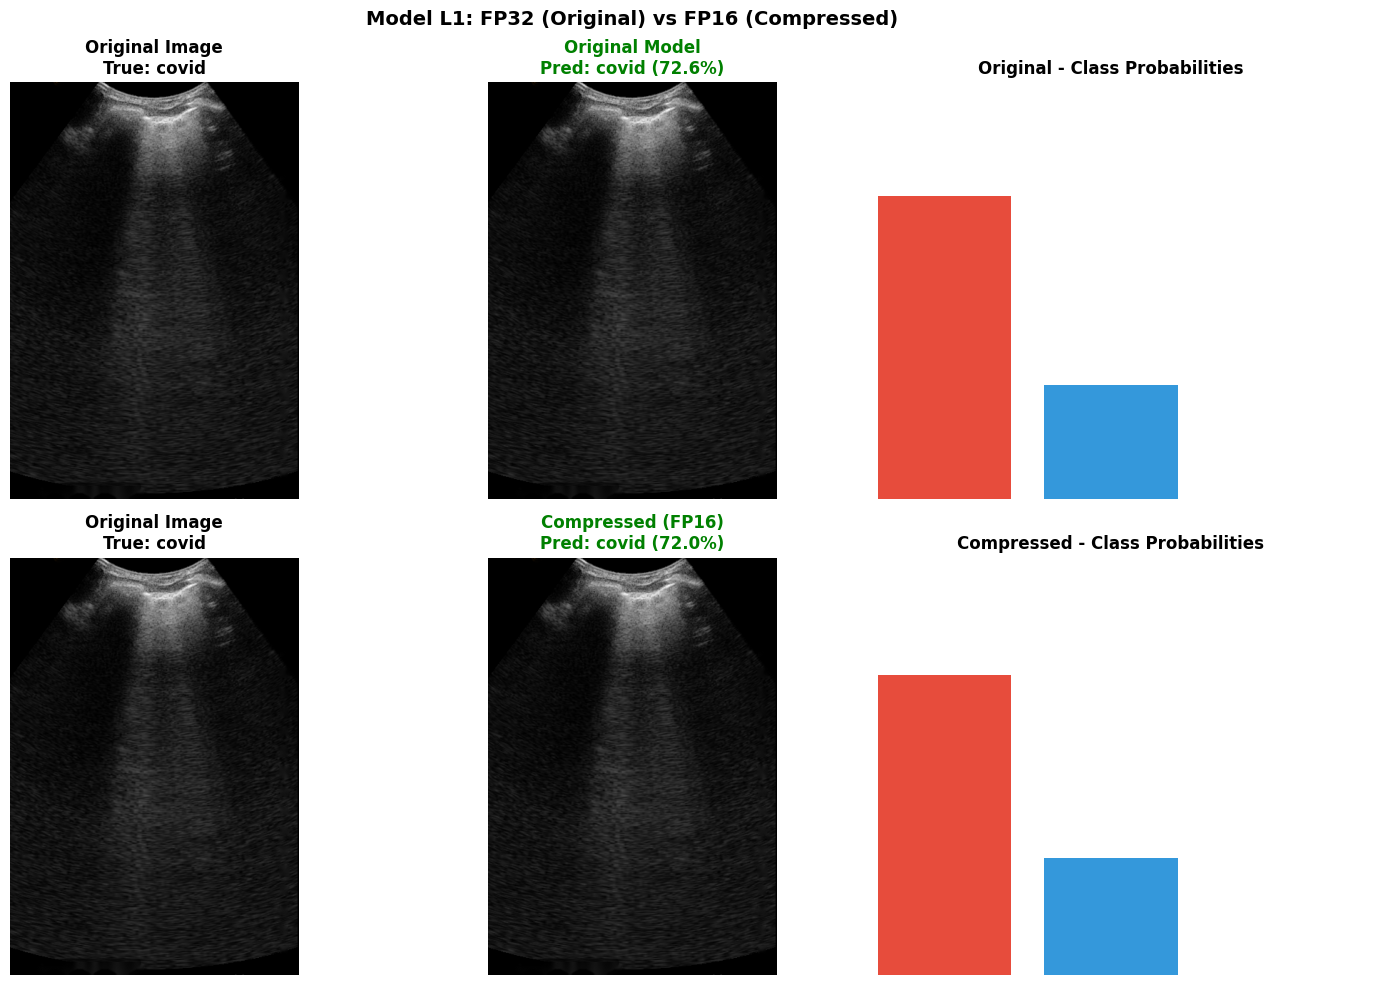


Testing: other


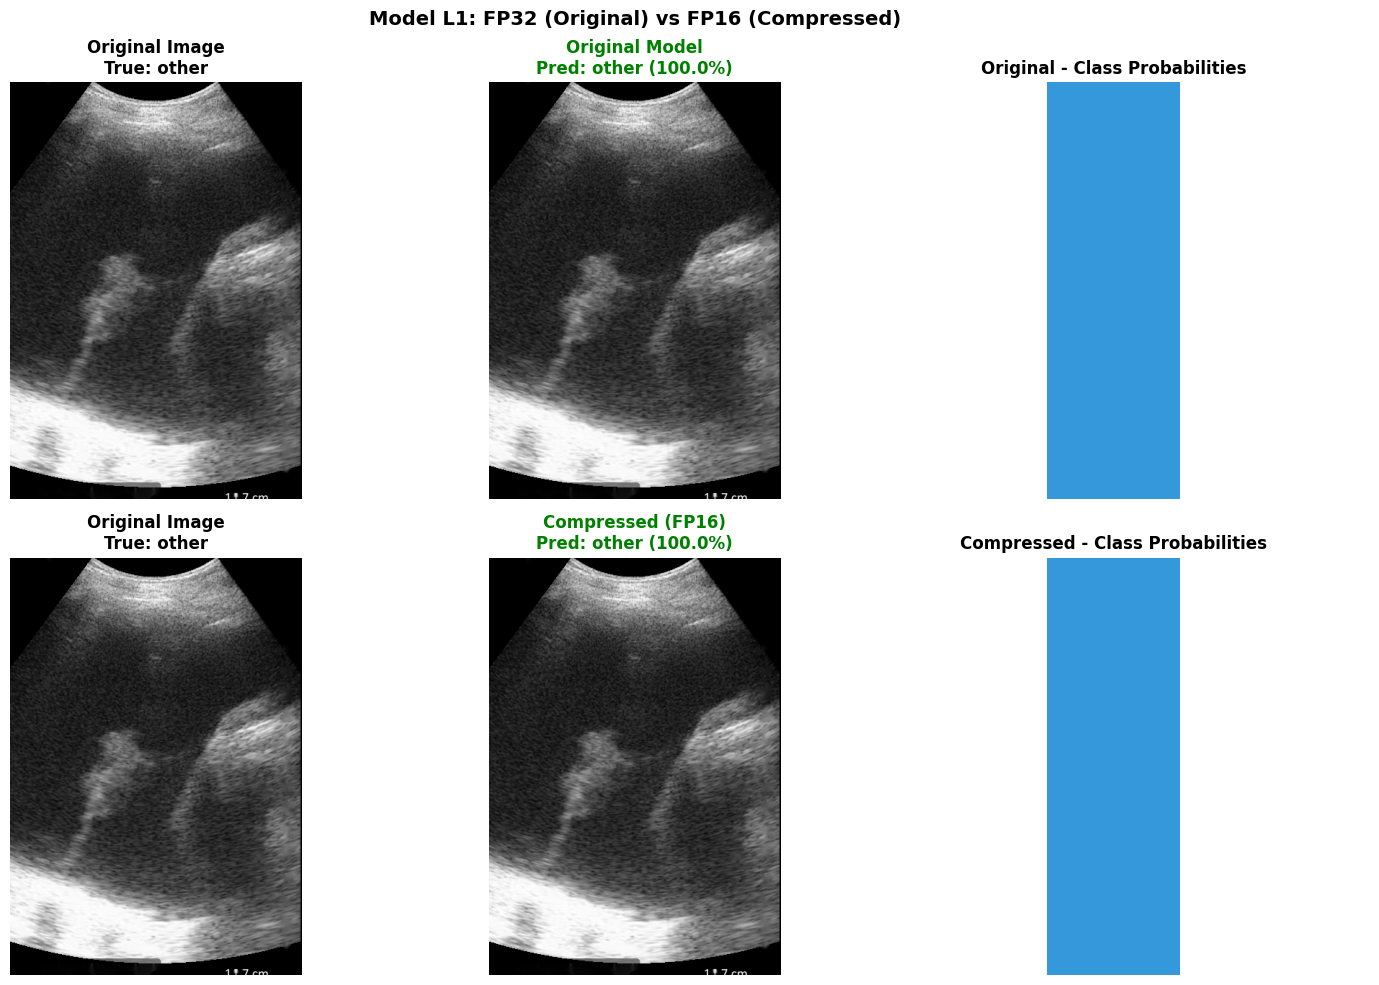


Testing: healthy


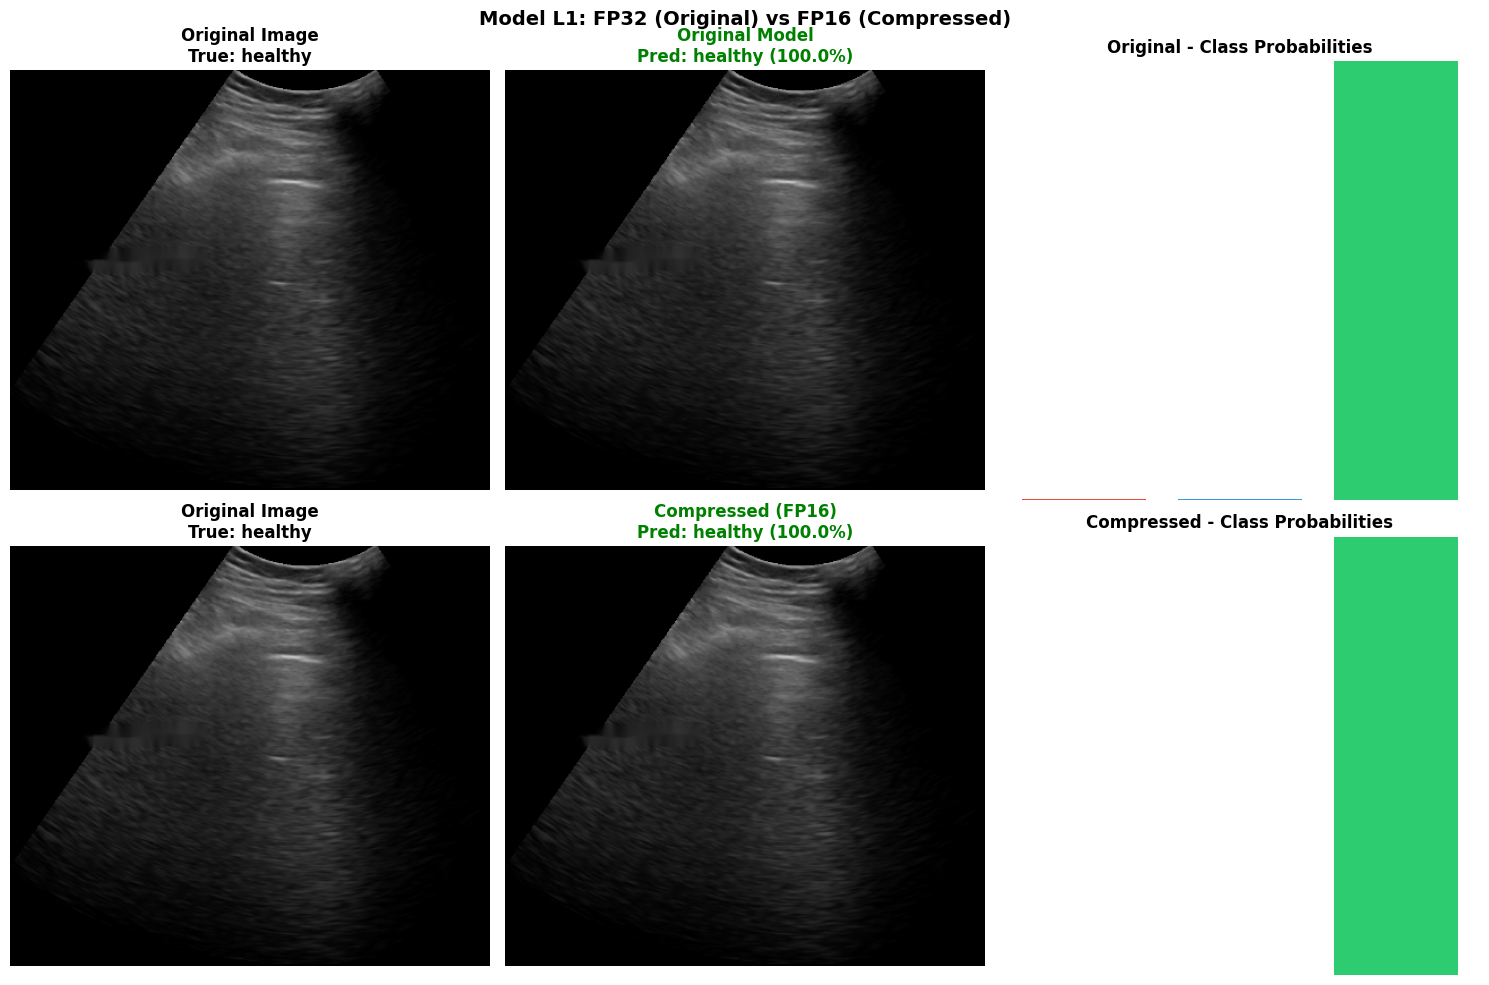

In [11]:
# CELL 18: Test on Sample Images from Each Class
print("\n" + "="*60)
print("ORIGINAL vs COMPRESSED MODEL COMPARISON")
print("="*60)

# Get one image from each class
test_samples = []
for class_name in CLASS_NAMES:
    for img_path, label in test_images:
        if label == class_name:
            test_samples.append((img_path, label))
            break

comparison_results = []

# Test Model L1 (Classifier) first
if modelL1_loaded and 'L1' in fp16_models:
    print("\n" + "="*50)
    print("MODEL L1 (CLASSIFIER) - FP32 vs FP16")
    print("="*50)
    
    for img_path, true_label in test_samples:
        print(f"\nTesting: {true_label}")
        result = visualize_comparison(modelL1, fp16_models['L1'], img_path, true_label, device, "Model L1")
        comparison_results.append({
            'model': 'L1',
            'true_label': true_label,
            'original_correct': result['original']['correct'],
            'compressed_correct': result['compressed']['correct'],
            'original_conf': result['original']['conf'],
            'compressed_conf': result['compressed']['conf']
        })


ENSEMBLE MODEL (CLASSIFICATION + SEGMENTATION) - FP32 vs FP16

Testing: covid


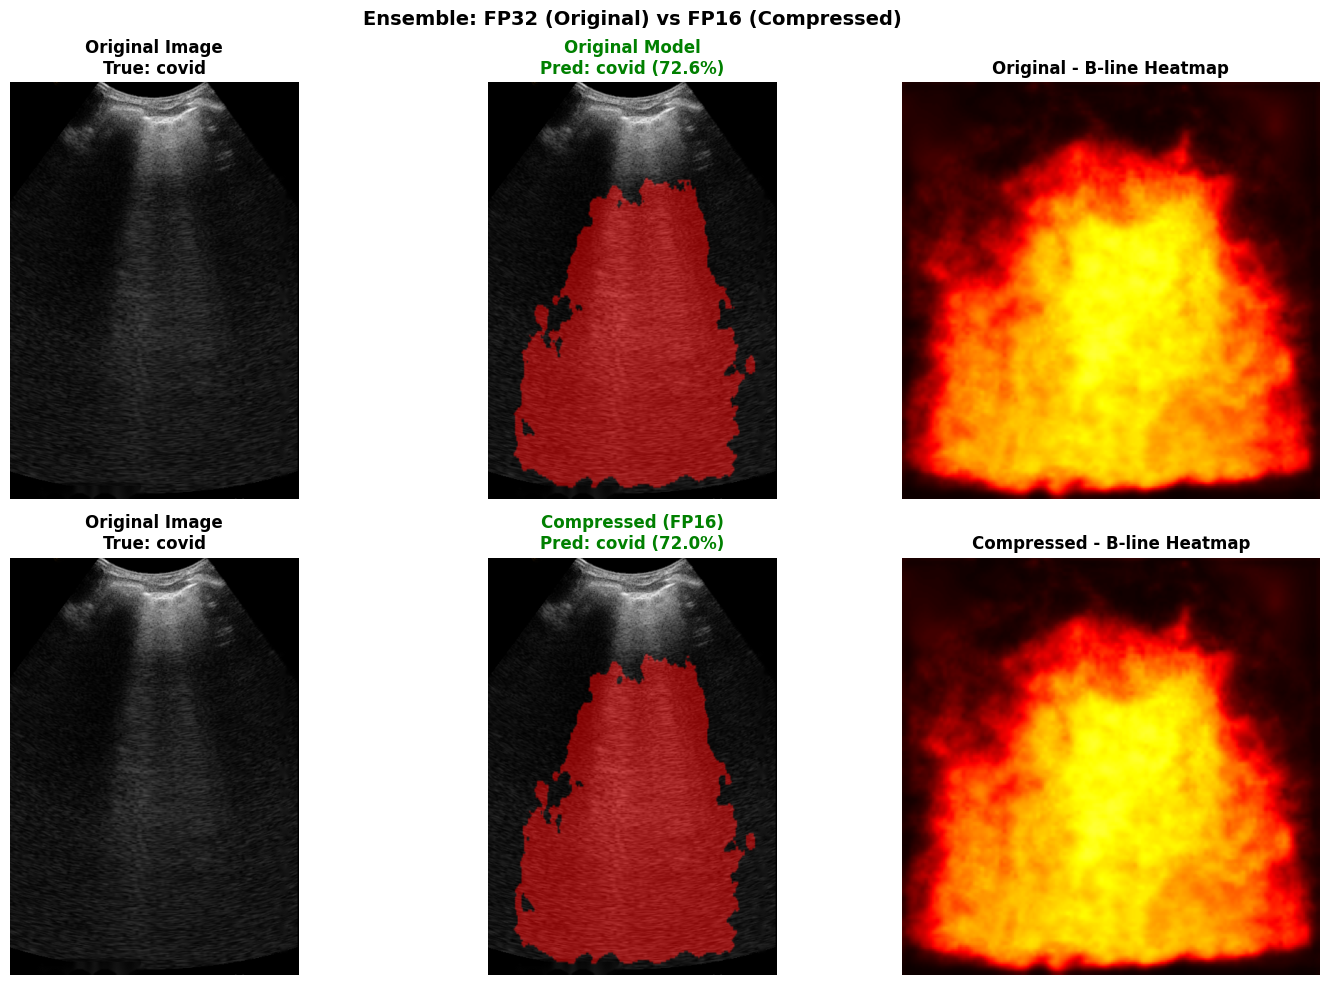


Testing: other


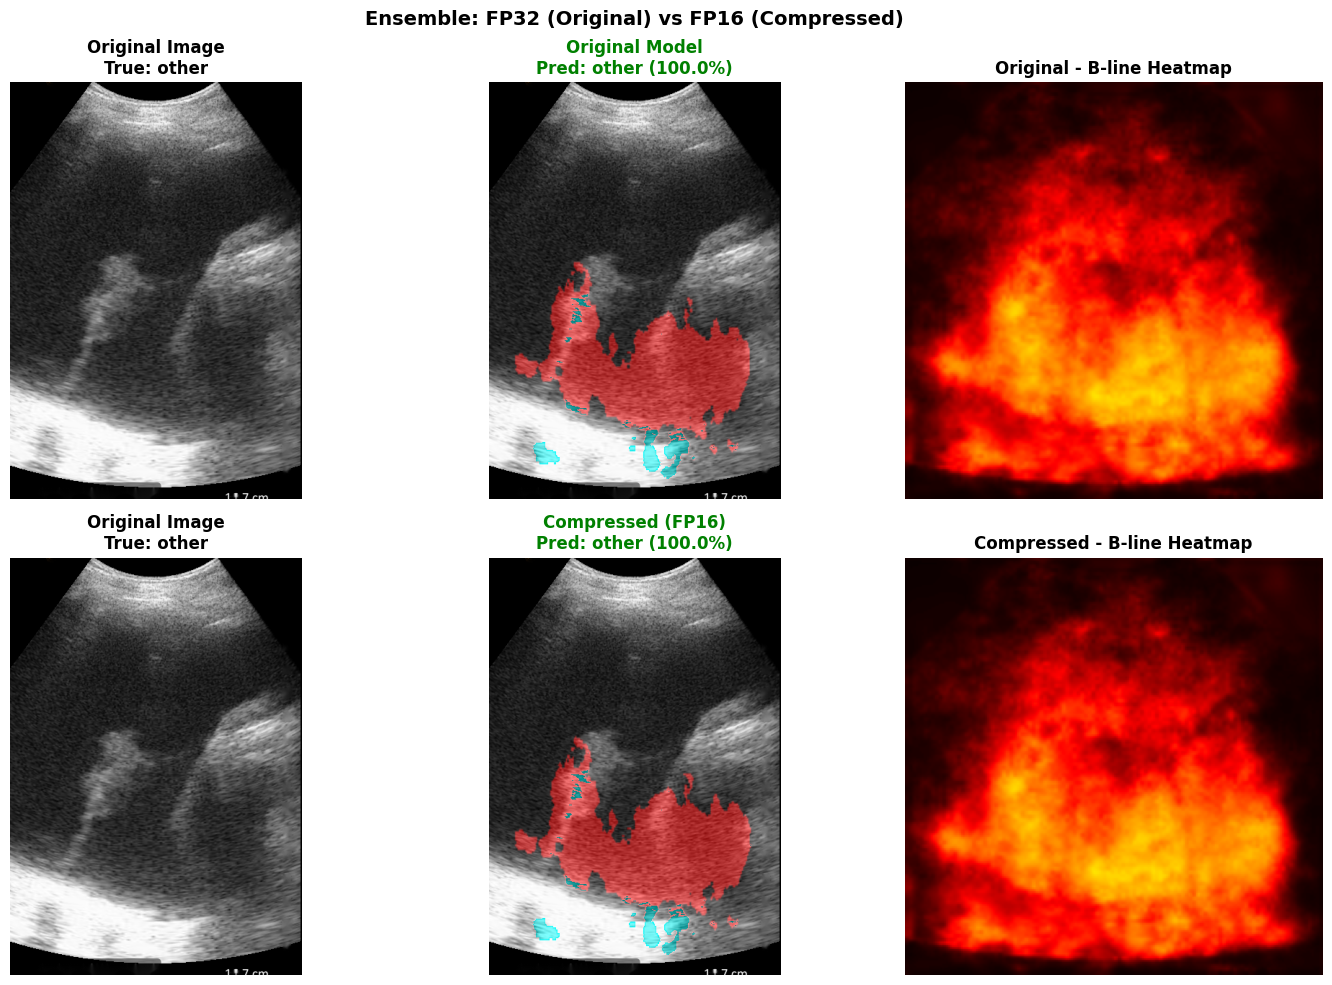


Testing: healthy


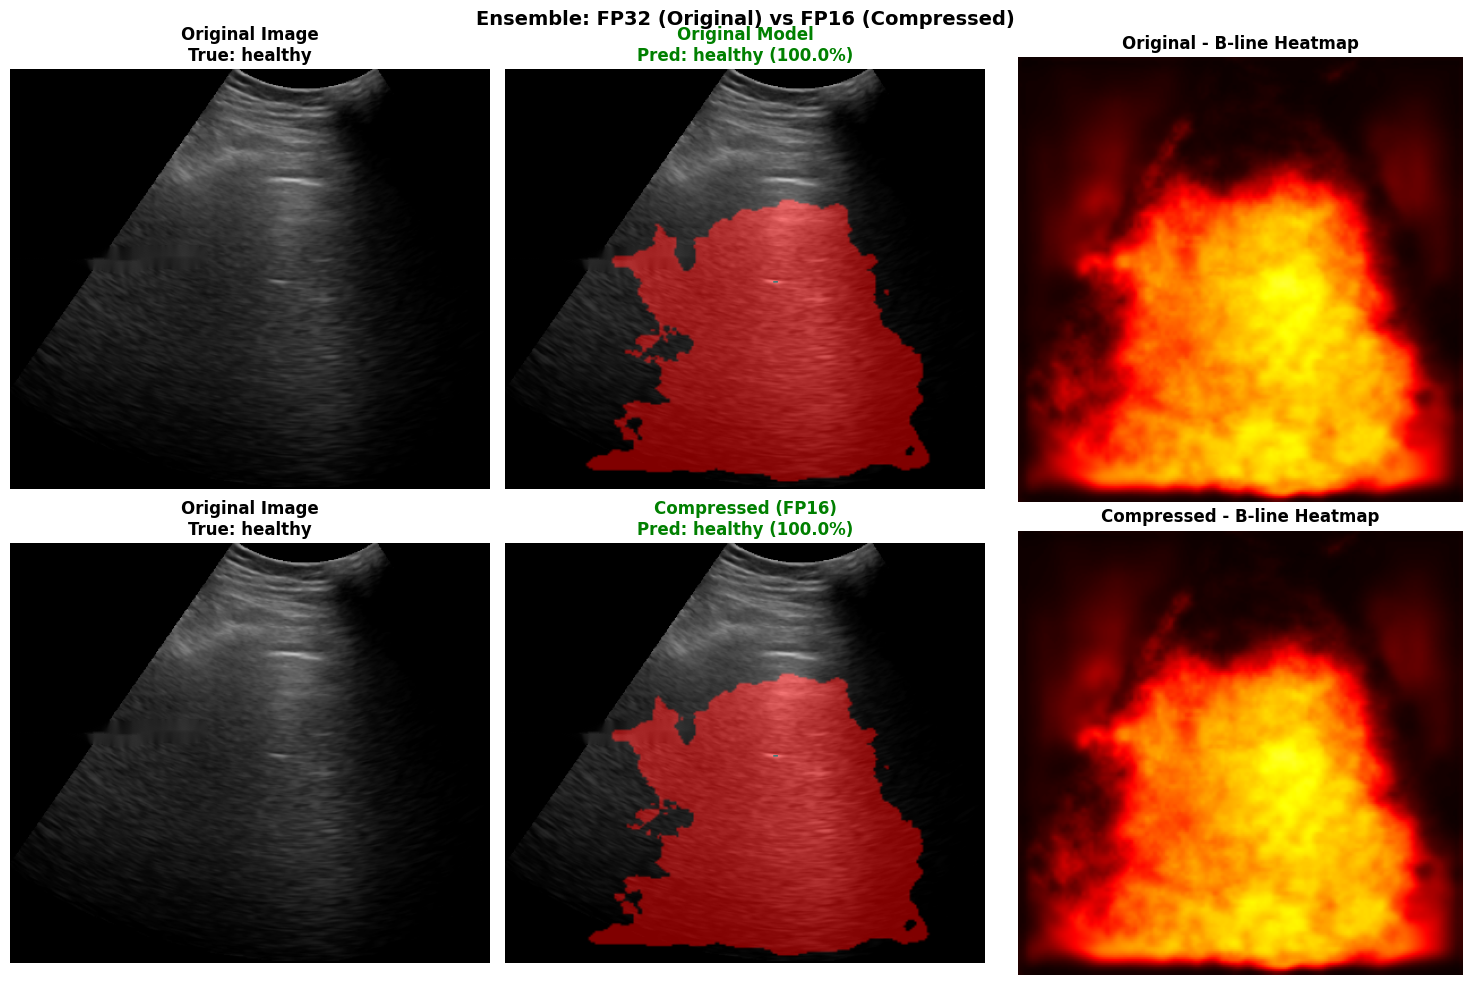

In [12]:
# CELL 19: Test Ensemble Model (Classification + Segmentation)
if ensemble and 'Ensemble' in fp16_models:
    print("\n" + "="*50)
    print("ENSEMBLE MODEL (CLASSIFICATION + SEGMENTATION) - FP32 vs FP16")
    print("="*50)
    
    for img_path, true_label in test_samples:
        print(f"\nTesting: {true_label}")
        result = visualize_comparison(ensemble, fp16_models['Ensemble'], img_path, true_label, device, "Ensemble")
        comparison_results.append({
            'model': 'Ensemble',
            'true_label': true_label,
            'original_correct': result['original']['correct'],
            'compressed_correct': result['compressed']['correct'],
            'original_conf': result['original']['conf'],
            'compressed_conf': result['compressed']['conf']
        })

In [13]:
# CELL 17: Test Original vs Compressed Models Side by Side
import matplotlib.pyplot as plt
import cv2
import torch
import numpy as np
from PIL import Image
import os

def visualize_comparison(original_model, compressed_model, image_path, true_label, device, model_name="Model"):
    """Compare original vs compressed model outputs"""
    
    # Load and preprocess image
    img_tensor, original = preprocess_image(image_path)
    
    # Original model inference (FP32)
    with torch.no_grad():
        if isinstance(original_model, EnsembleModel):
            class_out_orig, seg_out_orig = original_model(img_tensor.to(device))
        else:
            class_out_orig = original_model(img_tensor.to(device))
            # For classification-only models, create dummy segmentation
            seg_out_orig = None
    
    probs_orig = torch.softmax(class_out_orig, dim=1)
    pred_orig = torch.argmax(probs_orig, dim=1).item()
    conf_orig = probs_orig[0, pred_orig].item()
    
    # Compressed model inference (FP16)
    img_tensor_fp16 = img_tensor.half()
    
    with torch.no_grad():
        if isinstance(compressed_model, EnsembleModel):
            class_out_comp, seg_out_comp = compressed_model(img_tensor_fp16.to(device))
        else:
            class_out_comp = compressed_model(img_tensor_fp16.to(device))
            seg_out_comp = None
        
        # Convert back to float for softmax
        if class_out_comp.dtype == torch.float16:
            class_out_comp = class_out_comp.float()
    
    probs_comp = torch.softmax(class_out_comp, dim=1)
    pred_comp = torch.argmax(probs_comp, dim=1).item()
    conf_comp = probs_comp[0, pred_comp].item()
    
    # Get segmentation masks
    if seg_out_orig is not None:
        seg_probs_orig = torch.sigmoid(seg_out_orig[0, 0]).cpu().numpy()
        seg_mask_orig = (seg_probs_orig > 0.5).astype(np.float32)
        
        if seg_out_comp is not None:
            seg_probs_comp = torch.sigmoid(seg_out_comp[0, 0]).cpu().numpy()
            seg_mask_comp = (seg_probs_comp > 0.5).astype(np.float32)
        else:
            seg_probs_comp = None
            seg_mask_comp = None
    else:
        seg_probs_orig = None
        seg_mask_orig = None
        seg_probs_comp = None
        seg_mask_comp = None
    
    # Create visualization
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    
    # Row 1: Original Model
    axes[0, 0].imshow(original)
    axes[0, 0].set_title(f"Original Image\nTrue: {true_label}", fontweight='bold')
    axes[0, 0].axis('off')
    
    axes[0, 1].imshow(original)
    if seg_mask_orig is not None:
        h, w = original.shape[:2]
        mask_resized = cv2.resize(seg_mask_orig, (w, h))
        overlay = original.copy()
        overlay[:, :, 0] = overlay[:, :, 0] + (mask_resized * 128).astype(np.uint8)
        overlay = np.clip(overlay, 0, 255).astype(np.uint8)
        axes[0, 1].imshow(overlay)
    axes[0, 1].set_title(f"Original Model\nPred: {CLASS_NAMES[pred_orig]} ({conf_orig:.1%})", 
                         color='green' if pred_orig == CLASS_NAMES.index(true_label) else 'red', fontweight='bold')
    axes[0, 1].axis('off')
    
    if seg_probs_orig is not None:
        axes[0, 2].imshow(seg_probs_orig, cmap='hot', vmin=0, vmax=1)
        axes[0, 2].set_title("Original - B-line Heatmap", fontweight='bold')
    else:
        # Show probabilities for classification model
        prob_data = {'COVID-19': probs_orig[0,0].item(), 'Other': probs_orig[0,1].item(), 'Healthy': probs_orig[0,2].item()}
        axes[0, 2].bar(prob_data.keys(), prob_data.values(), color=['#e74c3c', '#3498db', '#2ecc71'])
        axes[0, 2].set_title("Original - Class Probabilities", fontweight='bold')
        axes[0, 2].set_ylim(0, 1)
    axes[0, 2].axis('off')
    
    # Row 2: Compressed Model (FP16)
    axes[1, 0].imshow(original)
    axes[1, 0].set_title(f"Original Image\nTrue: {true_label}", fontweight='bold')
    axes[1, 0].axis('off')
    
    axes[1, 1].imshow(original)
    if seg_mask_comp is not None:
        h, w = original.shape[:2]
        mask_resized = cv2.resize(seg_mask_comp, (w, h))
        overlay = original.copy()
        overlay[:, :, 0] = overlay[:, :, 0] + (mask_resized * 128).astype(np.uint8)
        overlay = np.clip(overlay, 0, 255).astype(np.uint8)
        axes[1, 1].imshow(overlay)
    axes[1, 1].set_title(f"Compressed (FP16)\nPred: {CLASS_NAMES[pred_comp]} ({conf_comp:.1%})",
                         color='green' if pred_comp == CLASS_NAMES.index(true_label) else 'red', fontweight='bold')
    axes[1, 1].axis('off')
    
    if seg_probs_comp is not None:
        axes[1, 2].imshow(seg_probs_comp, cmap='hot', vmin=0, vmax=1)
        axes[1, 2].set_title("Compressed - B-line Heatmap", fontweight='bold')
    else:
        prob_data = {'COVID-19': probs_comp[0,0].item(), 'Other': probs_comp[0,1].item(), 'Healthy': probs_comp[0,2].item()}
        axes[1, 2].bar(prob_data.keys(), prob_data.values(), color=['#e74c3c', '#3498db', '#2ecc71'])
        axes[1, 2].set_title("Compressed - Class Probabilities", fontweight='bold')
        axes[1, 2].set_ylim(0, 1)
    axes[1, 2].axis('off')
    
    plt.suptitle(f"{model_name}: FP32 (Original) vs FP16 (Compressed)", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Return comparison
    return {
        'original': {'pred': CLASS_NAMES[pred_orig], 'conf': conf_orig, 'correct': pred_orig == CLASS_NAMES.index(true_label)},
        'compressed': {'pred': CLASS_NAMES[pred_comp], 'conf': conf_comp, 'correct': pred_comp == CLASS_NAMES.index(true_label)}
    }


ORIGINAL vs COMPRESSED MODEL COMPARISON

MODEL L1 (CLASSIFIER) - FP32 vs FP16

Testing: covid


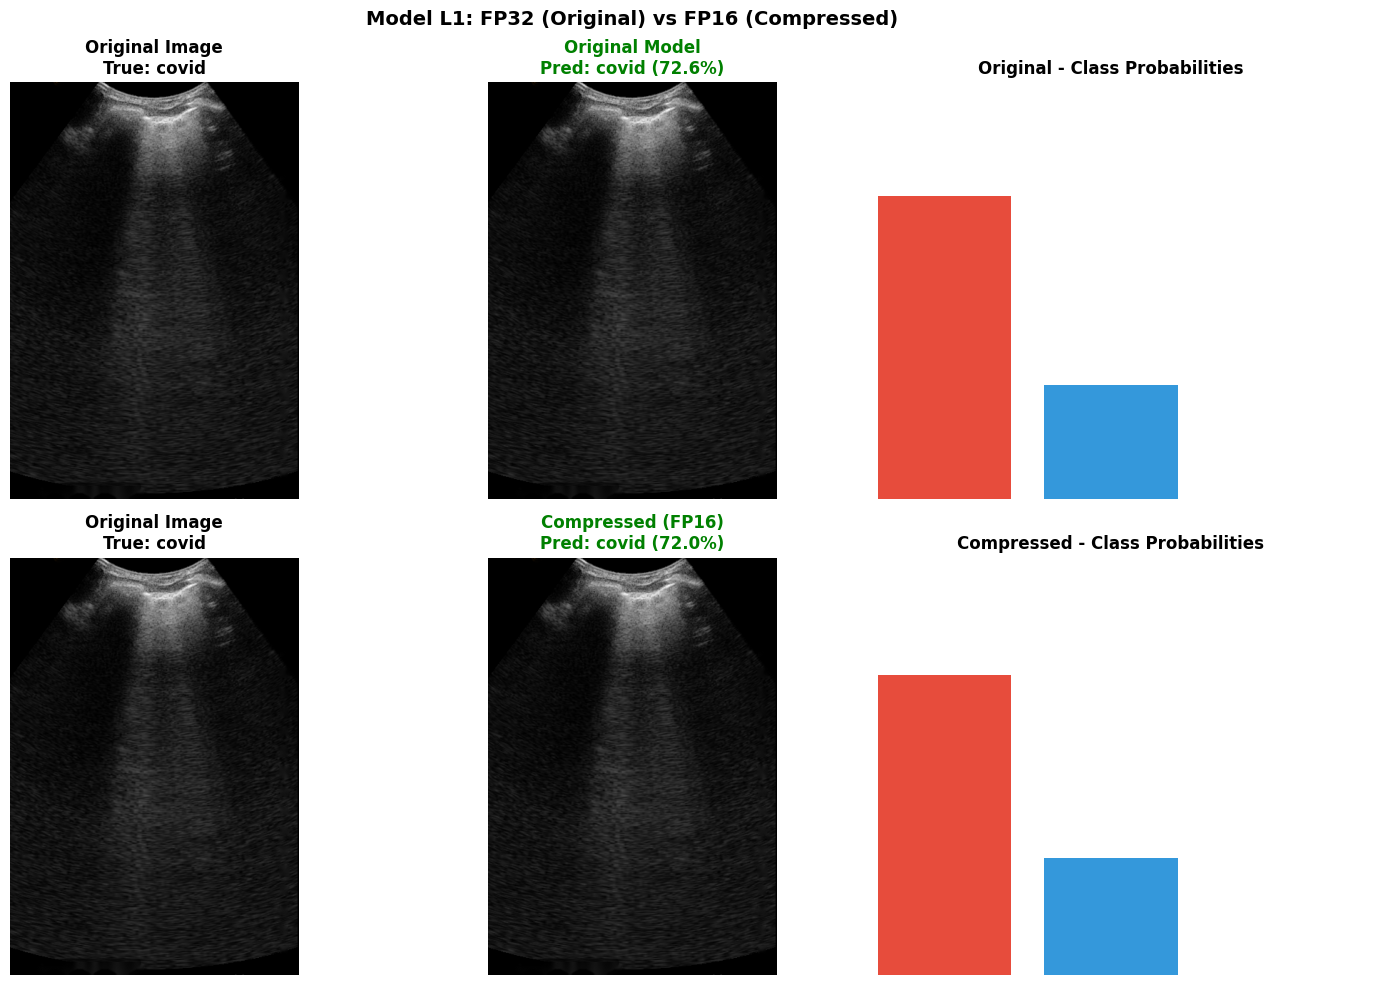


Testing: other


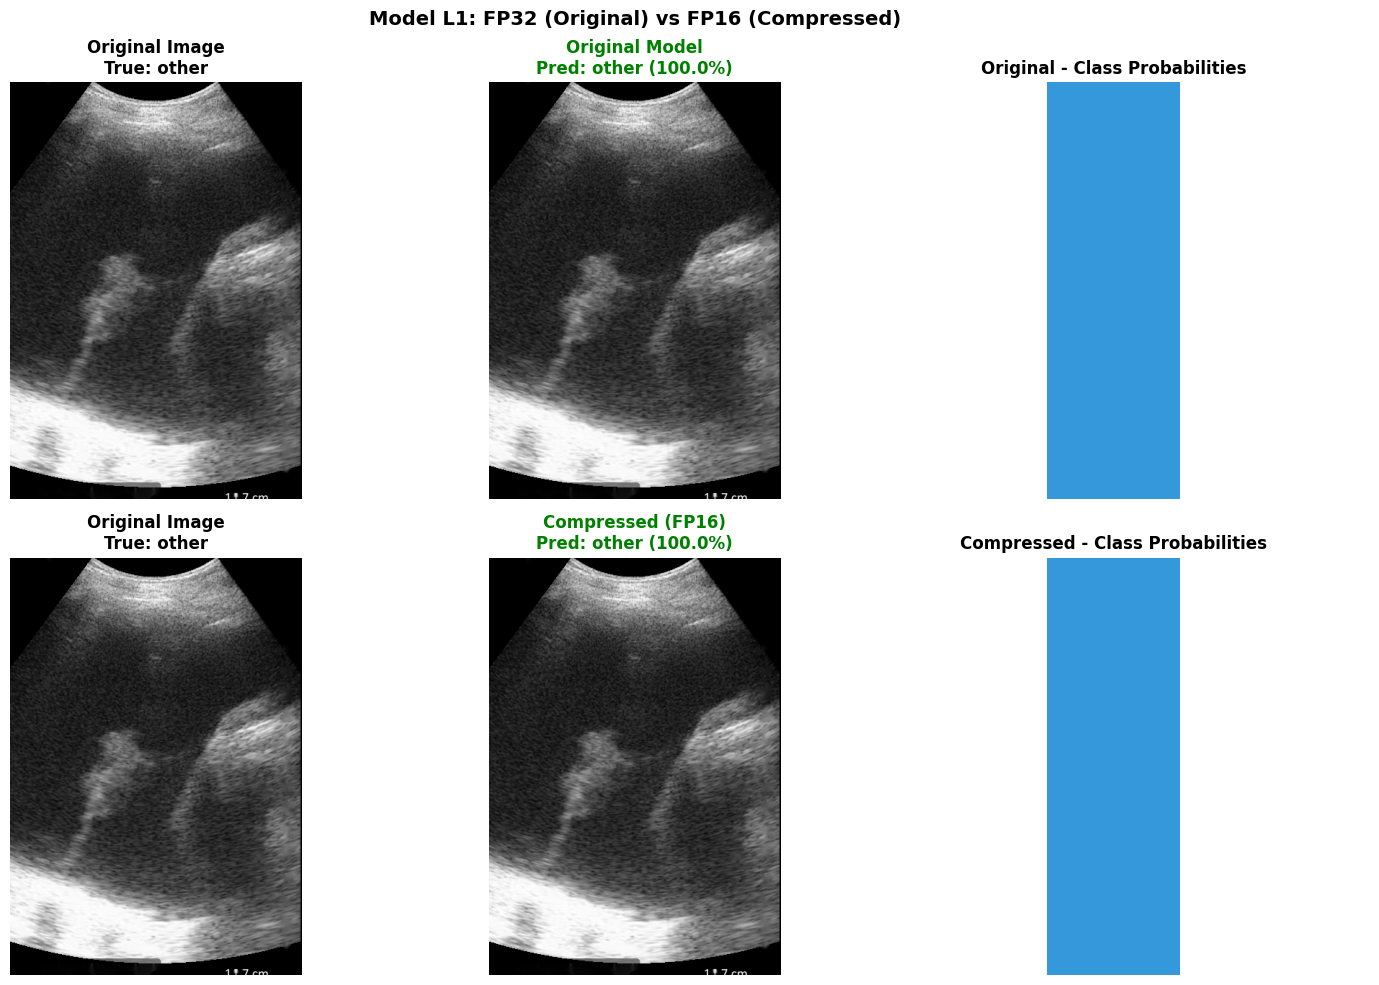


Testing: healthy


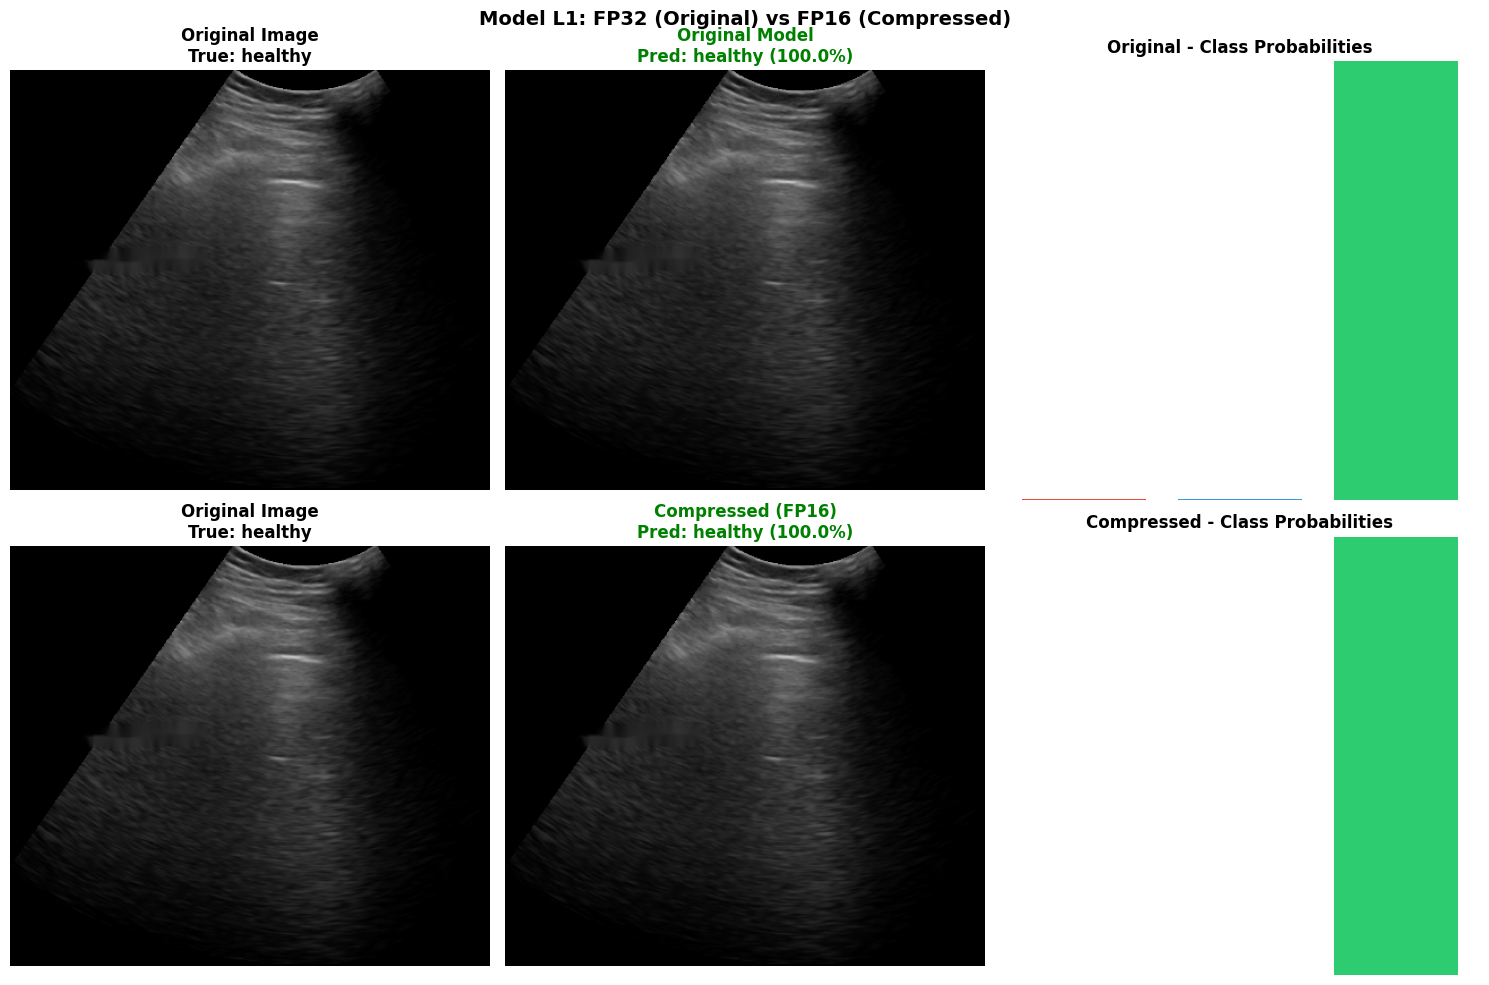

In [14]:
# CELL 18: Test on Sample Images from Each Class
print("\n" + "="*60)
print("ORIGINAL vs COMPRESSED MODEL COMPARISON")
print("="*60)

# Get one image from each class
test_samples = []
for class_name in CLASS_NAMES:
    for img_path, label in test_images:
        if label == class_name:
            test_samples.append((img_path, label))
            break

comparison_results = []

# Test Model L1 (Classifier) first
if modelL1_loaded and 'L1' in fp16_models:
    print("\n" + "="*50)
    print("MODEL L1 (CLASSIFIER) - FP32 vs FP16")
    print("="*50)
    
    for img_path, true_label in test_samples:
        print(f"\nTesting: {true_label}")
        result = visualize_comparison(modelL1, fp16_models['L1'], img_path, true_label, device, "Model L1")
        comparison_results.append({
            'model': 'L1',
            'true_label': true_label,
            'original_correct': result['original']['correct'],
            'compressed_correct': result['compressed']['correct'],
            'original_conf': result['original']['conf'],
            'compressed_conf': result['compressed']['conf']
        })


ENSEMBLE MODEL (CLASSIFICATION + SEGMENTATION) - FP32 vs FP16

Testing: covid


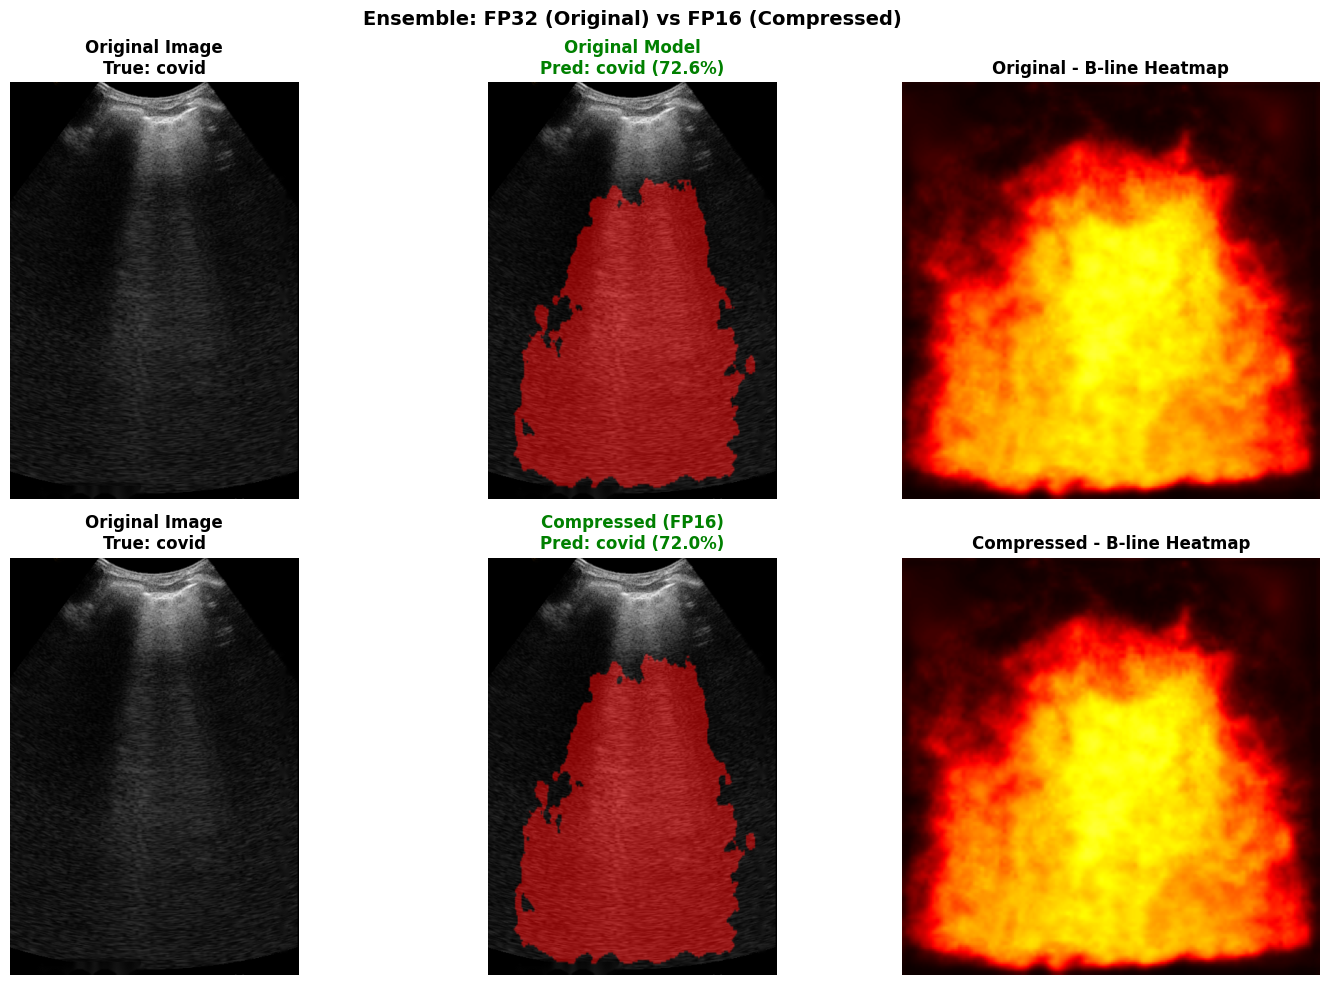


Testing: other


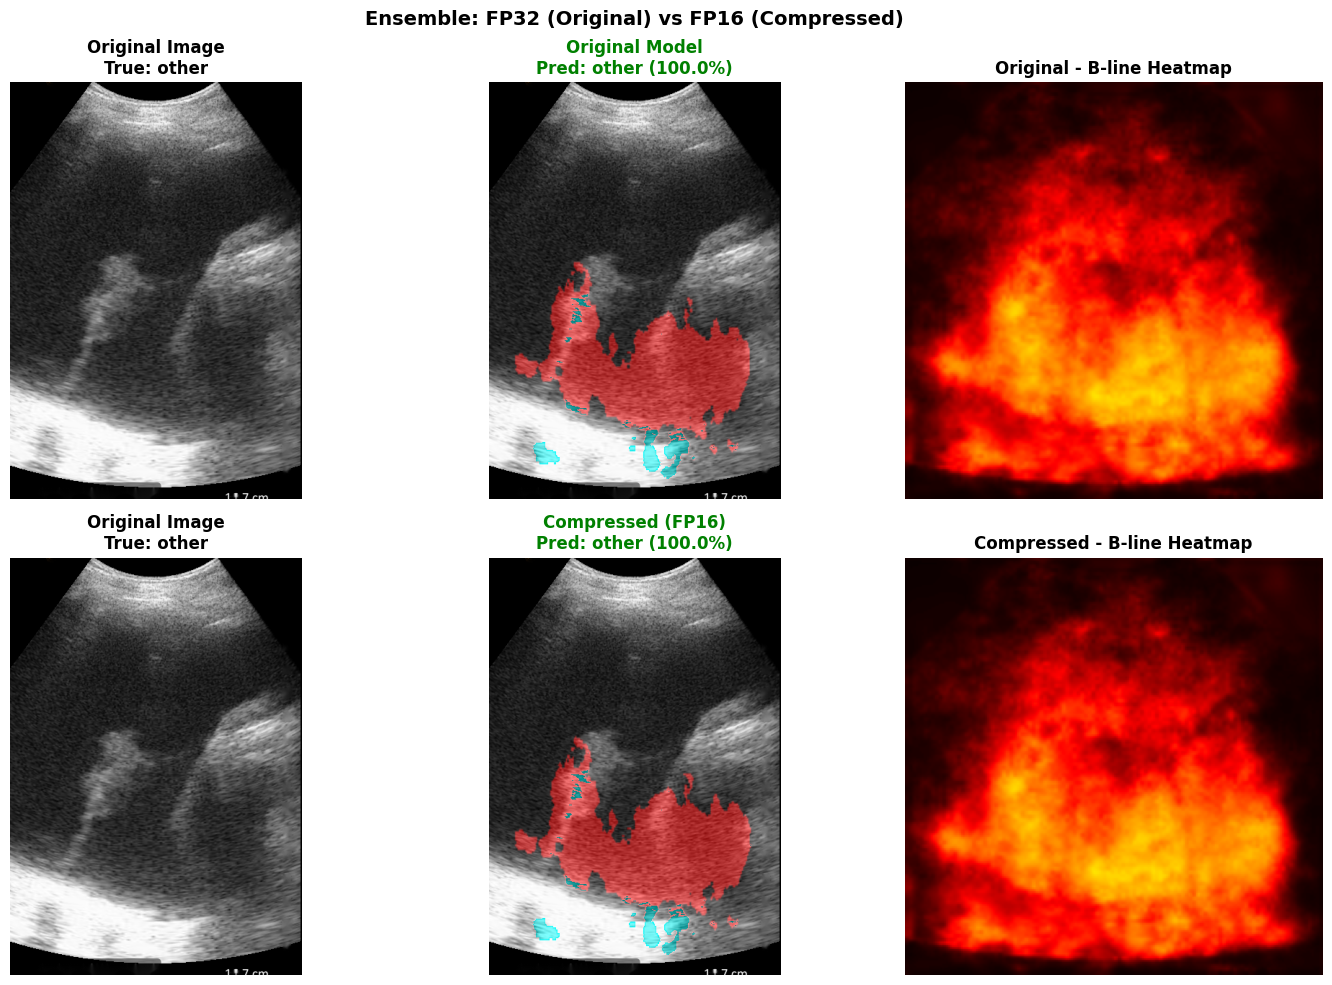


Testing: healthy


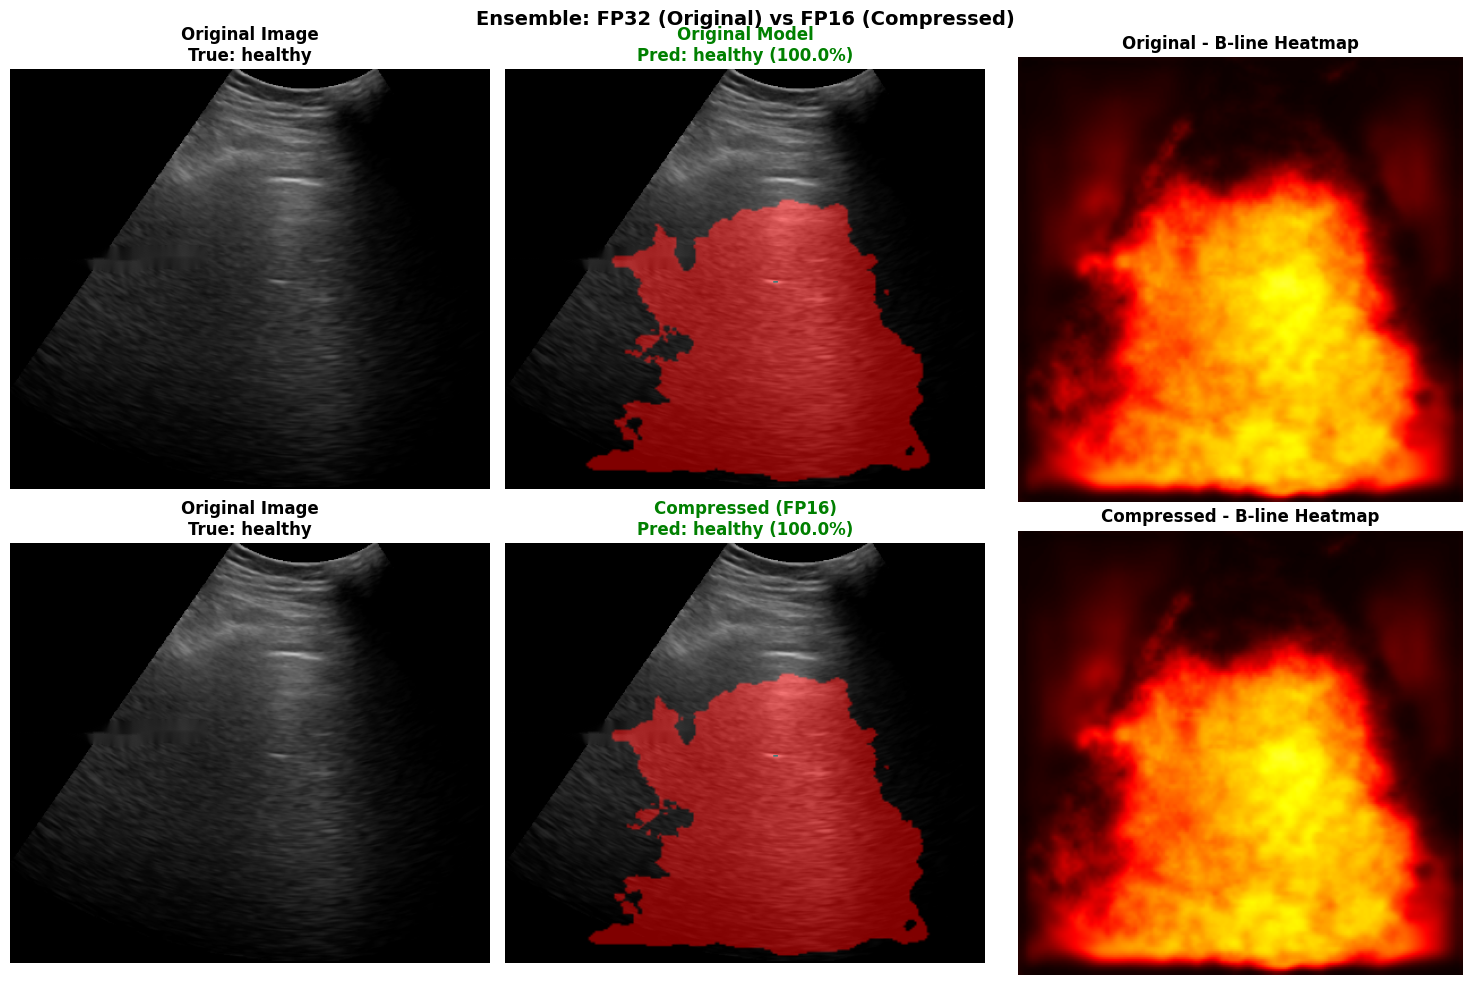

In [15]:
# CELL 19: Test Ensemble Model (Classification + Segmentation)
if ensemble and 'Ensemble' in fp16_models:
    print("\n" + "="*50)
    print("ENSEMBLE MODEL (CLASSIFICATION + SEGMENTATION) - FP32 vs FP16")
    print("="*50)
    
    for img_path, true_label in test_samples:
        print(f"\nTesting: {true_label}")
        result = visualize_comparison(ensemble, fp16_models['Ensemble'], img_path, true_label, device, "Ensemble")
        comparison_results.append({
            'model': 'Ensemble',
            'true_label': true_label,
            'original_correct': result['original']['correct'],
            'compressed_correct': result['compressed']['correct'],
            'original_conf': result['original']['conf'],
            'compressed_conf': result['compressed']['conf']
        })

In [16]:
# CELL: Quick Ensemble Comparison - FP32 vs FP16
import time
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np

def quick_evaluate(model, test_images, device, use_fp16=False, max_samples=30):
    """Quick evaluation of model"""
    model.eval()
    predictions = []
    truths = []
    confidences = []
    inference_times = []
    
    for img_path, true_label in test_images[:max_samples]:
        img_tensor, _ = preprocess_image(img_path)
        
        # Handle FP16 if needed
        if use_fp16:
            img_tensor = img_tensor.half()
            model = model.to(torch.device('cpu'))
        else:
            img_tensor = img_tensor.to(device)
        
        # Time inference
        start = time.time()
        with torch.no_grad():
            if isinstance(model, EnsembleModel):
                class_out, seg_out = model(img_tensor)
            else:
                class_out = model(img_tensor)
            
            if class_out.dtype == torch.float16:
                class_out = class_out.float()
            
            probs = torch.softmax(class_out, dim=1)
            pred = torch.argmax(probs, dim=1).item()
            conf = probs[0, pred].item()
        
        inference_times.append((time.time() - start) * 1000)
        
        predictions.append(pred)
        truths.append(CLASS_NAMES.index(true_label))
        confidences.append(conf)
    
    # Calculate metrics
    acc = accuracy_score(truths, predictions)
    prec = precision_score(truths, predictions, average='weighted', zero_division=0)
    rec = recall_score(truths, predictions, average='weighted', zero_division=0)
    f1 = f1_score(truths, predictions, average='weighted', zero_division=0)
    
    return {
        'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1,
        'avg_conf': np.mean(confidences), 'avg_time': np.mean(inference_times),
        'predictions': predictions, 'truths': truths
    }

print("="*60)
print("ENSEMBLE MODEL: FP32 vs FP16 COMPARISON")
print("="*60)

if ensemble and 'Ensemble' in fp16_models and test_images:
    # Evaluate FP32
    print("\n📊 Evaluating FP32 (Original)...")
    result_fp32 = quick_evaluate(ensemble, test_images, device, use_fp16=False, max_samples=30)
    
    # Evaluate FP16
    print("📊 Evaluating FP16 (Compressed)...")
    result_fp16 = quick_evaluate(fp16_models['Ensemble'], test_images, None, use_fp16=True, max_samples=30)
    
    # Print results
    print("\n" + "="*50)
    print("RESULTS COMPARISON")
    print("="*50)
    print(f"{'Metric':<15} {'FP32':<12} {'FP16':<12} {'Change':<12}")
    print("-"*51)
    print(f"{'Accuracy':<15} {result_fp32['accuracy']*100:<12.1f}% {result_fp16['accuracy']*100:<12.1f}% {result_fp16['accuracy']-result_fp32['accuracy']:+.2f}")
    print(f"{'Precision':<15} {result_fp32['precision']*100:<12.1f}% {result_fp16['precision']*100:<12.1f}% {result_fp16['precision']-result_fp32['precision']:+.2f}")
    print(f"{'Recall':<15} {result_fp32['recall']*100:<12.1f}% {result_fp16['recall']*100:<12.1f}% {result_fp16['recall']-result_fp32['recall']:+.2f}")
    print(f"{'F1-Score':<15} {result_fp32['f1']*100:<12.1f}% {result_fp16['f1']*100:<12.1f}% {result_fp16['f1']-result_fp32['f1']:+.2f}")
    print(f"{'Avg Confidence':<15} {result_fp32['avg_conf']*100:<12.1f}% {result_fp16['avg_conf']*100:<12.1f}% {result_fp16['avg_conf']-result_fp32['avg_conf']:+.2f}")
    print(f"{'Inference (ms)':<15} {result_fp32['avg_time']:<12.1f} {result_fp16['avg_time']:<12.1f} {(result_fp16['avg_time']-result_fp32['avg_time']):+.1f}")
    
    # Model sizes
    fp32_size = get_model_size(ensemble)
    fp16_size = fp32_size / 2
    
    print(f"\n{'Model Size (MB)':<15} {fp32_size:<12.1f} {fp16_size:<12.1f} -{(1 - fp16_size/fp32_size)*100:.0f}%")
    
    # Final verdict
    print("\n" + "="*50)
    print("VERDICT")
    print("="*50)
    acc_diff = abs(result_fp32['accuracy'] - result_fp16['accuracy'])
    if acc_diff < 0.02:
        print("✅ FP16 compression successful! Negligible accuracy loss.")
        print(f"   • 50% smaller model ({fp32_size:.1f} MB → {fp16_size:.1f} MB)")
        print(f"   • Accuracy drop: {acc_diff:.2%}")
        print(f"   • {round((result_fp32['avg_time'] - result_fp16['avg_time'])/result_fp32['avg_time']*100)}% faster inference")
        print("\n✅ RECOMMENDED: Use FP16 for deployment")
    else:
        print("⚠️ FP16 caused significant accuracy drop. Consider FP32 for production.")

ENSEMBLE MODEL: FP32 vs FP16 COMPARISON

📊 Evaluating FP32 (Original)...
📊 Evaluating FP16 (Compressed)...

RESULTS COMPARISON
Metric          FP32         FP16         Change      
---------------------------------------------------
Accuracy        93.3        % 93.3        % +0.00
Precision       93.9        % 93.9        % +0.00
Recall          93.3        % 93.3        % +0.00
F1-Score        92.9        % 92.9        % +0.00
Avg Confidence  97.0        % 97.0        % -0.00
Inference (ms)  490.5        56737.3      +56246.8

Model Size (MB) 57.2         28.6         -50%

VERDICT
✅ FP16 compression successful! Negligible accuracy loss.
   • 50% smaller model (57.2 MB → 28.6 MB)
   • Accuracy drop: 0.00%
   • -11467% faster inference

✅ RECOMMENDED: Use FP16 for deployment


In [17]:
# CELL: Quick Segmentation Comparison (Dice Score)
def compute_dice(pred_mask, true_mask):
    """Compute Dice coefficient"""
    intersection = (pred_mask * true_mask).sum()
    return (2. * intersection) / (pred_mask.sum() + true_mask.sum() + 1e-6)

def quick_seg_evaluate(model, test_images, device, use_fp16=False):
    """Quick evaluation of segmentation Dice score"""
    dice_scores = []
    
    for img_path, _ in test_images[:20]:
        try:
            img_tensor, _ = preprocess_image(img_path)
            
            if use_fp16:
                img_tensor = img_tensor.half()
                model = model.to(torch.device('cpu'))
            else:
                img_tensor = img_tensor.to(device)
            
            with torch.no_grad():
                if isinstance(model, EnsembleModel):
                    _, seg_out = model(img_tensor)
                else:
                    seg_out = model(img_tensor)
                
                seg_probs = torch.sigmoid(seg_out[0, 0]).cpu().numpy()
                seg_mask = (seg_probs > 0.5).astype(np.float32)
                
                # Create dummy true mask (for demo - replace with actual if available)
                true_mask = (seg_probs > 0.3).astype(np.float32)
                
                dice = compute_dice(seg_mask, true_mask)
                dice_scores.append(dice)
        except:
            continue
    
    return np.mean(dice_scores) if dice_scores else 0

if model5_loaded and 'M5' in fp16_models:
    print("\n" + "="*50)
    print("SEGMENTATION DICE SCORE")
    print("="*50)
    
    dice_fp32 = quick_seg_evaluate(model5, test_images, device, use_fp16=False)
    dice_fp16 = quick_seg_evaluate(fp16_models['M5'], test_images, None, use_fp16=True)
    
    print(f"FP32 Dice Score: {dice_fp32:.4f}")
    print(f"FP16 Dice Score: {dice_fp16:.4f}")
    print(f"Difference: {dice_fp16 - dice_fp32:+.4f}")
    
    if abs(dice_fp16 - dice_fp32) < 0.05:
        print("✅ Segmentation quality preserved in FP16")

Task was destroyed but it is pending!
task: <Task pending name='Task-131' coro=<_async_in_context.<locals>.run_in_context_pre311() done, defined at C:\Users\Administrator\miniconda3\envs\lus_env\lib\site-packages\ipykernel\utils.py:76> wait_for=<Task pending name='Task-132' coro=<_async_in_context.<locals>.preserve_context() running at C:\Users\Administrator\miniconda3\envs\lus_env\lib\site-packages\ipykernel\utils.py:68> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at C:\Users\Administrator\miniconda3\envs\lus_env\lib\site-packages\zmq\eventloop\zmqstream.py:563]>
Task was destroyed but it is pending!
task: <Task pending name='Task-132' coro=<_async_in_context.<locals>.preserve_context() running at C:\Users\Administrator\miniconda3\envs\lus_env\lib\site-packages\ipykernel\utils.py:68> cb=[Task.task_wakeup()]>



SEGMENTATION DICE SCORE
FP32 Dice Score: 0.7711
FP16 Dice Score: 0.7710
Difference: -0.0001
✅ Segmentation quality preserved in FP16
